In [54]:
# ==============================================================================
# PHASE 1: COHORT CONSTRUCTION & EPIDEMIOLOGICAL ATTRITION ANALYSIS
# Strict De Novo MASLD Prediction (Excluding ALL Baseline Steatosis)
# ==============================================================================
import numpy as np
import pandas as pd
from IPython.display import display
from tableone import TableOne
import warnings
warnings.filterwarnings('ignore')

print("Loading data...")
df = pd.read_csv("Updated_MASLD.csv")
print(f"--- 1. INITIAL COHORT ---")
print(f"Total participants completing baseline assessment: {len(df)}")

def yn_to01(s):
    return s.astype('string').str.strip().str.lower().map(
        {'yes': 1, 'y': 1, '1': 1, 'true': 1, 'no': 0, 'n': 0, '0': 0, 'false': 0}
    ).astype('Int64')

# 1. Feature Engineering
bp_cols = ['sbp1_1', 'sbp1_2', 'dbp1_1', 'dbp1_2']
df[bp_cols] = df[bp_cols].apply(pd.to_numeric, errors='coerce')
df['sbp_mean'] = df[['sbp1_1', 'sbp1_2']].mean(axis=1)
df['dbp_mean'] = df[['dbp1_1', 'dbp1_2']].mean(axis=1)

df['measureweight_1'] = pd.to_numeric(df['measureweight_1'], errors='coerce')
df['measurelength_1'] = pd.to_numeric(df['measurelength_1'], errors='coerce')
h_m = df['measurelength_1'] / 100.0
valid = (df['measureweight_1'] > 0) & (h_m > 0)
df['BMI (kg/m^2)'] = np.where(valid, df['measureweight_1'] / (h_m ** 2), np.nan)

# 2. Detailed Sequential Baseline Exclusions (For Flowchart Diagram)
print("\n--- 2. BASELINE EXCLUSIONS (Detailed Breakdown) ---")
df['m_masld_1_clean'] = yn_to01(df['m_masld_1'])
df['m_sld_1_clean'] = yn_to01(df['m_sld_1'])
df['m_cirrhosis_1'] = pd.to_numeric(df['m_cirrhosis_1'], errors='coerce')

# Boolean masks for exclusions 
mask_baseline_masld = (df['m_masld_1_clean'] == 1).fillna(False)
mask_isolated_steatosis = (df['m_sld_1_clean'] == 1).fillna(False) # Now fully excluded
mask_hepatitis = df[['m_hbsag_1', 'm_hcvab_1']].eq('Yes').any(axis=1).fillna(False)
mask_cirrhosis = (df['m_cirrhosis_1'] == 1).fillna(False)

print(f" - Prevalent MASLD: {mask_baseline_masld.sum()}")
print(f" - Isolated Steatosis (Reviewer Comment 3): {mask_isolated_steatosis.sum()}")
print(f" - Viral Hepatitis (HBsAg or HCVAb positive): {mask_hepatitis.sum()}")
print(f" - Cirrhosis: {mask_cirrhosis.sum()}")

# Calculate overlaps
sum_masks_exclusion = mask_baseline_masld.astype(int) + mask_isolated_steatosis.astype(int) + mask_hepatitis.astype(int) + mask_cirrhosis.astype(int)
overlap_count = (sum_masks_exclusion > 1).sum()
print(f" * Overlapping categories (participants with >1 of the exclusion criteria): {overlap_count}")

# Identify total UNIQUE participants excluded at baseline
mask_invalid_baseline = mask_baseline_masld | mask_isolated_steatosis | mask_hepatitis | mask_cirrhosis
print(f"=> Total Unique Participants Excluded at Baseline: {mask_invalid_baseline.sum()}")

# 3. Establish Eligible At-Risk Baseline Cohort
df_eligible_baseline = df[~mask_invalid_baseline].copy()
print(f"\n--- 3. ELIGIBLE AT-RISK BASELINE COHORT ---")
print(f"Total eligible participants strictly without any steatosis: {len(df_eligible_baseline)}")

# 4. Target Definition & Loss to Follow-up on Eligible Cohort
df_eligible_baseline['m_masld_2_clean'] = yn_to01(df_eligible_baseline['m_masld_2'])
inc_raw = df_eligible_baseline['m_masld_incidence'].astype('string').str.strip().str.lower()
df_eligible_baseline['inc_clean'] = inc_raw.map({'incidence': 1, 'negative': 0, 'regress': pd.NA}).astype('Int64')

df_eligible_baseline['target'] = df_eligible_baseline['inc_clean'].copy()
need_fill = df_eligible_baseline['target'].isna() & df_eligible_baseline['m_masld_2_clean'].notna()
df_eligible_baseline.loc[need_fill, 'target'] = df_eligible_baseline.loc[need_fill, 'm_masld_2_clean']

# Mask for participants with valid 7-year outcomes
mask_retained = df_eligible_baseline['target'].notna() & (inc_raw.fillna('') != 'regress')

print(f"\n--- 4. FOLLOW-UP STATUS (7-Year Outcome) ---")
print(f" - Retained (Included in Final Analysis): {mask_retained.sum()}")
print(f" - Lost to Follow-up (or unanalyzable outcome): {(~mask_retained).sum()}")

# 5. Standardized Mean Difference (SMD) Calculation for Selection Bias
print("\n--- 5. SMD METRICS FOR SELECTION BIAS (Retained vs. Lost to Follow-up) ---")
smd_results = []

# Continuous Variables
key_vars_cont = ['age_m', 'BMI (kg/m^2)', 'alt_1', 'ast_1', 'tg_1', 'sbp_mean']
for var in key_vars_cont:
    df_eligible_baseline[var] = pd.to_numeric(df_eligible_baseline[var], errors='coerce')
    retained_vals = df_eligible_baseline.loc[mask_retained, var].dropna()
    lost_vals = df_eligible_baseline.loc[~mask_retained, var].dropna()
    
    mean_ret, std_ret = retained_vals.mean(), retained_vals.std()
    mean_lost, std_lost = lost_vals.mean(), lost_vals.std()
    
    pooled_sd = np.sqrt((std_ret**2 + std_lost**2) / 2)
    smd = np.abs(mean_ret - mean_lost) / pooled_sd if pooled_sd > 0 else np.nan
        
    smd_results.append({"Variable": var, "Retained Mean (SD)": f"{mean_ret:.1f} ({std_ret:.1f})", "Lost Mean (SD)": f"{mean_lost:.1f} ({std_lost:.1f})", "SMD": f"{smd:.3f}"})

# Categorical Variables (Proportions)
key_vars_cat = ['sex', 'm_t2dm_1', 'm_htnm_1', 'm_smoke_1']
for var in key_vars_cat:
    temp_series = df_eligible_baseline[var].astype('string').str.strip().str.lower()
    temp_series = temp_series.map({'m': 1, 'male': 1, 'f': 0, 'female': 0}) if var == 'sex' else temp_series.map({'yes': 1, 'y': 1, '1': 1, 'true': 1, 'no': 0, 'n': 0, '0': 0, 'false': 0})
    
    retained_vals = temp_series[mask_retained].dropna()
    lost_vals = temp_series[~mask_retained].dropna()
    p1, p2 = retained_vals.mean(), lost_vals.mean()
    
    pooled_var = (p1 * (1 - p1) + p2 * (1 - p2)) / 2
    smd = np.abs(p1 - p2) / np.sqrt(pooled_var) if pooled_var > 0 else np.nan
    smd_results.append({"Variable": var + " (Proportion)", "Retained Mean (SD)": f"{p1:.3f}", "Lost Mean (SD)": f"{p2:.3f}", "SMD": f"{smd:.3f}"})

smd_df = pd.DataFrame(smd_results).set_index("Variable")
display(smd_df)

# 6. Finalize the Dataset for Predictive Modeling
df_final = df_eligible_baseline[mask_retained].copy()
print(f"\n---> FINAL STRICT DE NOVO ANALYTICAL COHORT SIZE: {len(df_final)}")

# Feature Matrix Preparation
model_vars = [
    'alt_1', 'ast_1', 'tg_1', 'hdl_1', 'ldl_1', 'sex', 'age_m',
    'm_hbsab_1', 'm_smoke_1', 'm_metsatp3_1', 'm_lipm_1', 'm_htnm_1',
    'm_t2dm_1', 'sbp_mean', 'dbp_mean', 'BMI (kg/m^2)'
]

X = df_final[model_vars].copy()
for c in X.columns:
    if X[c].dtype == "object" or X[c].dtype == "string":
        s = X[c].astype("string").str.strip().str.lower()
        s = s.replace({"m": "1", "male": "1", "f": "0", "female": "0"}) if c.lower() == 'sex' else s.replace({"yes": "1", "no": "0", "true": "1", "false": "0"})
        X[c] = pd.to_numeric(s, errors='coerce')

y = df_final['target'].astype(int).copy()

Loading data...
--- 1. INITIAL COHORT ---
Total participants completing baseline assessment: 5394

--- 2. BASELINE EXCLUSIONS (Detailed Breakdown) ---
 - Prevalent MASLD: 1824
 - Isolated Steatosis (Reviewer Comment 3): 2153
 - Viral Hepatitis (HBsAg or HCVAb positive): 59
 - Cirrhosis: 174
 * Overlapping categories (participants with >1 of the exclusion criteria): 1873
=> Total Unique Participants Excluded at Baseline: 2282

--- 3. ELIGIBLE AT-RISK BASELINE COHORT ---
Total eligible participants strictly without any steatosis: 3112

--- 4. FOLLOW-UP STATUS (7-Year Outcome) ---
 - Retained (Included in Final Analysis): 2361
 - Lost to Follow-up (or unanalyzable outcome): 751

--- 5. SMD METRICS FOR SELECTION BIAS (Retained vs. Lost to Follow-up) ---


,Retained Mean (SD),Lost Mean (SD),SMD
Variable,,,
age_m,42.7 (15.2),46.0 (22.2),0.175
BMI (kg/m^2),25.7 (4.6),24.2 (4.8),0.319
alt_1,20.3 (13.4),19.0 (14.6),0.095
ast_1,21.0 (8.5),21.6 (10.2),0.058
tg_1,115.1 (76.6),104.1 (64.7),0.155
sbp_mean,112.5 (14.8),112.2 (17.1),0.017
sex (Proportion),0.573,0.630,0.116
m_t2dm_1 (Proportion),0.025,0.029,0.026
m_htnm_1 (Proportion),0.054,0.083,0.112



---> FINAL STRICT DE NOVO ANALYTICAL COHORT SIZE: 2361


Generating Plausibility Plots (Observed vs. Imputed Distributions)...


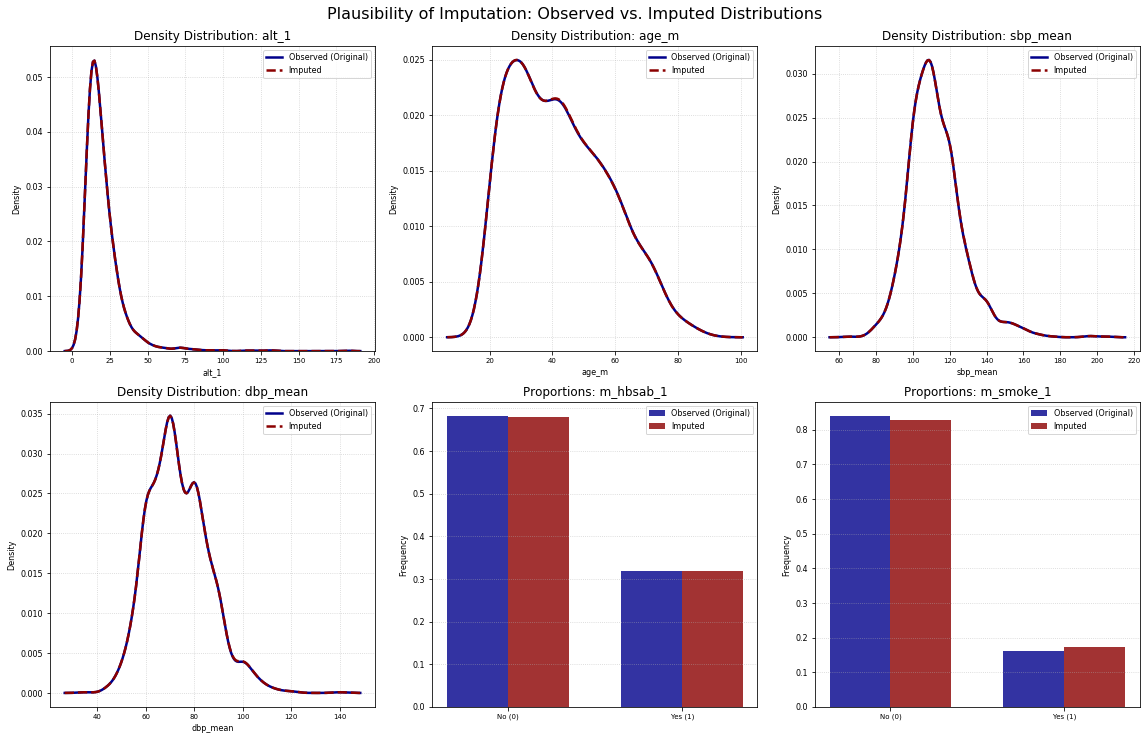

Plot saved successfully as 'Supplementary_Figure_Imputation_Plausibility.png'


In [26]:
# ==============================================================================
# EXTRA PHASE: IMPUTATION PLAUSIBILITY CHECK (For Supplementary Figure)
# Addressing Reviewer Comment 1 (Assessing plausibility of imputed values)
# ==============================================================================
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("Generating Plausibility Plots (Observed vs. Imputed Distributions)...")

# متغیرهایی که در فاز 3 دیدیم دارای مقادیر گمشده (Missing) بودند
cont_missing = ['alt_1', 'age_m', 'sbp_mean', 'dbp_mean']
cat_missing = ['m_hbsab_1', 'm_smoke_1']

# تنظیم ابعاد نمودار (2 ردیف و 3 ستون)
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

# 1. رسم نمودار چگالی (Density) برای متغیرهای پیوسته
for i, col in enumerate(cont_missing):
    # داده‌های اصلی (فقط ردیف‌هایی که مقدار دارند)
    sns.kdeplot(X_train[col].dropna(), color='darkblue', label='Observed (Original)', ax=axes[i], linewidth=2.5)
    # داده‌های Impute شده (کامل)
    sns.kdeplot(X_train_imp[col], color='darkred', linestyle='--', label='Imputed', ax=axes[i], linewidth=2.5)
    
    axes[i].set_title(f'Density Distribution: {col}', fontsize=12)
    axes[i].set_ylabel('Density')
    axes[i].legend()
    axes[i].grid(True, linestyle=':', alpha=0.6)

# 2. رسم نمودار میله‌ای (Bar Plot) برای متغیرهای باینری
for i, col in enumerate(cat_missing):
    idx = i + len(cont_missing)
    
    # محاسبه نسبت‌ها (Proportions)
    obs_prop = X_train[col].dropna().value_counts(normalize=True).sort_index()
    imp_prop = X_train_imp[col].value_counts(normalize=True).sort_index()
    
    x = np.arange(len(obs_prop))
    width = 0.35
    
    axes[idx].bar(x - width/2, obs_prop, width, label='Observed (Original)', color='darkblue', alpha=0.8)
    axes[idx].bar(x + width/2, imp_prop, width, label='Imputed', color='darkred', alpha=0.8)
    
    axes[idx].set_xticks(x)
    axes[idx].set_xticklabels(['No (0)', 'Yes (1)'])
    axes[idx].set_title(f'Proportions: {col}', fontsize=12)
    axes[idx].set_ylabel('Frequency')
    axes[idx].legend()
    axes[idx].grid(axis='y', linestyle=':', alpha=0.6)

# حذف کادرهای خالی احتمالی
for j in range(len(cont_missing) + len(cat_missing), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Plausibility of Imputation: Observed vs. Imputed Distributions', fontsize=16, y=1.02)
plt.tight_layout()

# ذخیره نمودار با کیفیت بالا برای ژورنال
plt.savefig('Supplementary_Figure_Imputation_Plausibility.png', dpi=400, bbox_inches='tight')
plt.show()

print("Plot saved successfully as 'Supplementary_Figure_Imputation_Plausibility.png'")

In [27]:
# ==============================================================================
# PHASE 2: BASELINE CHARACTERISTICS (TABLE 1)
# Addressing Reviewer Comment 4 (Clarifying Diagnosis vs. Medication)
# ==============================================================================
df_table1 = X.copy()
df_table1['Incident_MASLD'] = y.values
df_table1['Incident_MASLD'] = df_table1['Incident_MASLD'].map({0: 'No MASLD (Healthy)', 1: 'Developed MASLD'})

cat_cols = ['sex', 'm_smoke_1', 'm_metsatp3_1', 'm_lipm_1', 'm_htnm_1', 'm_t2dm_1', 'm_hbsab_1']
for col in cat_cols:
    if col in df_table1.columns:
        if col == 'sex':
            df_table1[col] = df_table1[col].map({0.0: 'Female', 1.0: 'Male'})
        else:
            df_table1[col] = df_table1[col].map({0.0: 'No', 1.0: 'Yes'})

columns_to_summarize = ['age_m', 'BMI (kg/m^2)', 'sbp_mean', 'dbp_mean', 'alt_1', 'ast_1', 'tg_1', 'hdl_1', 'ldl_1'] + cat_cols
non_normal_variables = ['alt_1', 'ast_1', 'tg_1']

# --- Reviewer Comment 4: Clarifying variable identities ---
rename_dict = {
    'age_m': 'Age (years)', 
    'sex': 'Sex', 
    'BMI (kg/m^2)': 'Body Mass Index (kg/m²)',
    'sbp_mean': 'Systolic BP (mmHg)', 
    'dbp_mean': 'Diastolic BP (mmHg)',
    'alt_1': 'ALT (U/L)', 
    'ast_1': 'AST (U/L)', 
    'tg_1': 'Triglycerides (mg/dL)',
    'hdl_1': 'HDL Cholesterol (mg/dL)', 
    'ldl_1': 'LDL Cholesterol (mg/dL)',
    'm_smoke_1': 'Current Smoker', 
    'm_metsatp3_1': 'Metabolic Syndrome (ATP III)',
    'm_lipm_1': 'Lipid-lowering Medication Use',
    'm_htnm_1': 'Antihypertensive Medication Use',
    'm_t2dm_1': 'Type 2 Diabetes Medication Use',
    'm_hbsab_1': 'HBsAb Positive'
}

df_table1 = df_table1.rename(columns=rename_dict)
updated_columns = [rename_dict.get(c, c) for c in columns_to_summarize]
updated_categorical = [rename_dict.get(c, c) for c in cat_cols]
updated_non_normal = [rename_dict.get(c, c) for c in non_normal_variables]

print("--- PHASE 2: BASELINE CHARACTERISTICS ---")
table1 = TableOne(
    data=df_table1, columns=updated_columns, categorical=updated_categorical,
    groupby='Incident_MASLD', nonnormal=updated_non_normal, pval=True, overall=True, missing=True 
)

print(table1.tabulate(tablefmt="github"))
table1.to_excel("Table1_Baseline_Characteristics_DeNovo.xlsx")

--- PHASE 2: BASELINE CHARACTERISTICS ---
|                                        |        | Missing   | Overall           | Developed MASLD    | No MASLD (Healthy)   | P-Value   |
|----------------------------------------|--------|-----------|-------------------|--------------------|----------------------|-----------|
| n                                      |        |           | 2361              | 612                | 1749                 |           |
| Age (years), mean (SD)                 |        | 6         | 42.7 (15.2)       | 42.9 (13.2)        | 42.6 (15.9)          | 0.645     |
| Body Mass Index (kg/m²), mean (SD)     |        | 0         | 25.7 (4.6)        | 28.2 (5.0)         | 24.8 (4.1)           | <0.001    |
| Systolic BP (mmHg), mean (SD)          |        | 1         | 112.5 (14.8)      | 115.2 (15.5)       | 111.5 (14.4)         | <0.001    |
| Diastolic BP (mmHg), mean (SD)         |        | 1         | 73.3 (12.2)       | 75.7 (12.5)        | 72.5 (12.1)  

In [28]:
# ==============================================================================
# PHASE 3: MISSING DATA REPORT & STOCHASTIC SINGLE ITERATIVE IMPUTATION
# Addressing Reviewer Comments #1 (Single Imputation) and #6 (Benchmarking)
# ==============================================================================
import pandas as pd
import numpy as np
from IPython.display import display

from sklearn.model_selection import train_test_split
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

RANDOM_STATE = 42

# 0. Split the CORRECTED cohort
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, stratify=y, random_state=RANDOM_STATE)
print(f"Dataset Split -> Train set: {len(X_train)} | Test set: {len(X_test)}\n")

# 1. Missing Data Report (Reviewer Comment 1)
print("--- 1. MISSING DATA REPORT BEFORE IMPUTATION ---")
missing_df = pd.DataFrame({
    'Missing Count': X.isnull().sum(),
    'Missing Percentage (%)': (X.isnull().mean() * 100)
})
missing_vars = missing_df[missing_df['Missing Count'] > 0].round(2)
if not missing_vars.empty:
    display(missing_vars)
else:
    print("No missing data found.")

# 2. Stochastic Single Iterative Imputation
print("\n--- 2. STOCHASTIC SINGLE ITERATIVE IMPUTATION (Convergence Logs) ---")
imputer_base = IterativeImputer(max_iter=10, sample_posterior=True, random_state=RANDOM_STATE, initial_strategy='mean', verbose=2)

X_train_imp = pd.DataFrame(imputer_base.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_imp = pd.DataFrame(imputer_base.transform(X_test), columns=X_test.columns, index=X_test.index)

# Binarize categorical columns post-imputation (Thresholding > 0.5)
binary_cols = ['sex', 'm_hbsab_1', 'm_smoke_1', 'm_metsatp3_1', 'm_lipm_1', 'm_htnm_1', 'm_t2dm_1']
for col in binary_cols:
    X_train_imp[col] = np.where(X_train_imp[col] > 0.5, 1.0, 0.0)
    X_test_imp[col] = np.where(X_test_imp[col] > 0.5, 1.0, 0.0)

# 3. Benchmarking Against Simpler Clinical Approaches (Reviewer Comment 6)
print("\n--- 3. BENCHMARKING AGAINST ESTABLISHED INDICES & SIMPLE MODELS ---")

# A) Parsimonious Benchmark Model (Age, BMI, ALT, TG)
simple_vars = ['age_m', 'BMI (kg/m^2)', 'alt_1', 'tg_1']
simple_model = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=1000, penalty='none', random_state=RANDOM_STATE)) 
])

simple_model.fit(X_train_imp[simple_vars], y_train)
y_prob_simple = simple_model.predict_proba(X_test_imp[simple_vars])[:, 1]
print(f"Parsimonious Model (4 variables) ROC-AUC: {roc_auc_score(y_test, y_prob_simple):.3f}")

# B) Hepatic Steatosis Index (HSI) Benchmark
# Formula: 8 * (ALT/AST ratio) + BMI + 2 (if diabetes) + 2 (if female)
hsi_test = 8 * (X_test_imp['alt_1'] / X_test_imp['ast_1']) + X_test_imp['BMI (kg/m^2)']
# Add 2 if female (sex == 0.0)
hsi_test += np.where(X_test_imp['sex'] == 0.0, 2, 0)
# Add 2 if T2DM (m_t2dm_1 == 1.0)
hsi_test += np.where(X_test_imp['m_t2dm_1'] == 1.0, 2, 0)

print(f"Hepatic Steatosis Index (HSI) ROC-AUC: {roc_auc_score(y_test, hsi_test):.3f}")


Dataset Split -> Train set: 1652 | Test set: 709

--- 1. MISSING DATA REPORT BEFORE IMPUTATION ---


,Missing Count,Missing Percentage (%)
alt_1,1,0.04
age_m,6,0.25
m_hbsab_1,115,4.87
m_smoke_1,294,12.45
sbp_mean,1,0.04
dbp_mean,1,0.04



--- 2. STOCHASTIC SINGLE ITERATIVE IMPUTATION (Convergence Logs) ---
[IterativeImputer] Completing matrix with shape (1652, 16)
[IterativeImputer] Ending imputation round 1/10, elapsed time 0.35
[IterativeImputer] Ending imputation round 2/10, elapsed time 0.54
[IterativeImputer] Ending imputation round 3/10, elapsed time 0.78
[IterativeImputer] Ending imputation round 4/10, elapsed time 1.05
[IterativeImputer] Ending imputation round 5/10, elapsed time 1.36
[IterativeImputer] Ending imputation round 6/10, elapsed time 1.57
[IterativeImputer] Ending imputation round 7/10, elapsed time 1.80
[IterativeImputer] Ending imputation round 8/10, elapsed time 2.36
[IterativeImputer] Ending imputation round 9/10, elapsed time 2.76
[IterativeImputer] Ending imputation round 10/10, elapsed time 3.20
[IterativeImputer] Completing matrix with shape (709, 16)
[IterativeImputer] Ending imputation round 1/10, elapsed time 0.03
[IterativeImputer] Ending imputation round 2/10, elapsed time 0.06
[Iterati

--- Phase 1: RandomizedSearchCV Hyperparameter Tuning (Reviewer Comment 8) ---
Tuning LogisticRegression...
[IterativeImputer] Completing matrix with shape (1652, 16)
[IterativeImputer] Ending imputation round 1/10, elapsed time 0.42
[IterativeImputer] Ending imputation round 2/10, elapsed time 0.62
[IterativeImputer] Ending imputation round 3/10, elapsed time 0.84
[IterativeImputer] Ending imputation round 4/10, elapsed time 1.08
[IterativeImputer] Ending imputation round 5/10, elapsed time 1.48
[IterativeImputer] Ending imputation round 6/10, elapsed time 1.79
[IterativeImputer] Ending imputation round 7/10, elapsed time 2.26
[IterativeImputer] Ending imputation round 8/10, elapsed time 2.59
[IterativeImputer] Ending imputation round 9/10, elapsed time 3.02
[IterativeImputer] Ending imputation round 10/10, elapsed time 3.42
  -> Best CV AUC: 0.720
  -> Selected Hyperparameters: {'clf__penalty': 'l2', 'clf__C': 0.1}
Tuning RandomForest...
[IterativeImputer] Completing matrix with shap

Threshold Optimization CV:   0%|          | 0/25 [00:00<?, ?it/s]

[IterativeImputer] Completing matrix with shape (1321, 16)
[IterativeImputer] Ending imputation round 1/10, elapsed time 0.81
[IterativeImputer] Ending imputation round 2/10, elapsed time 1.77
[IterativeImputer] Ending imputation round 3/10, elapsed time 2.39
[IterativeImputer] Ending imputation round 4/10, elapsed time 3.30
[IterativeImputer] Ending imputation round 5/10, elapsed time 4.38
[IterativeImputer] Ending imputation round 6/10, elapsed time 5.41
[IterativeImputer] Ending imputation round 7/10, elapsed time 6.17
[IterativeImputer] Ending imputation round 8/10, elapsed time 7.08
[IterativeImputer] Ending imputation round 9/10, elapsed time 8.07
[IterativeImputer] Ending imputation round 10/10, elapsed time 9.07
[IterativeImputer] Completing matrix with shape (331, 16)
[IterativeImputer] Ending imputation round 1/10, elapsed time 0.02
[IterativeImputer] Ending imputation round 2/10, elapsed time 0.06
[IterativeImputer] Ending imputation round 3/10, elapsed time 0.08
[IterativeI

Threshold Optimization CV:   4%|▍         | 1/25 [00:09<03:59,  9.99s/it]

[IterativeImputer] Completing matrix with shape (1321, 16)
[IterativeImputer] Ending imputation round 1/10, elapsed time 0.88
[IterativeImputer] Ending imputation round 2/10, elapsed time 1.90
[IterativeImputer] Ending imputation round 3/10, elapsed time 2.63
[IterativeImputer] Ending imputation round 4/10, elapsed time 3.35
[IterativeImputer] Ending imputation round 5/10, elapsed time 4.40
[IterativeImputer] Ending imputation round 6/10, elapsed time 6.34
[IterativeImputer] Ending imputation round 7/10, elapsed time 7.27
[IterativeImputer] Ending imputation round 8/10, elapsed time 8.44
[IterativeImputer] Ending imputation round 9/10, elapsed time 10.67
[IterativeImputer] Ending imputation round 10/10, elapsed time 10.98
[IterativeImputer] Completing matrix with shape (331, 16)
[IterativeImputer] Ending imputation round 1/10, elapsed time 0.03
[IterativeImputer] Ending imputation round 2/10, elapsed time 0.06
[IterativeImputer] Ending imputation round 3/10, elapsed time 0.08
[Iterativ

...

Threshold Optimization CV: 100%|██████████| 25/25 [03:47<00:00,  9.08s/it]

[IterativeImputer] Ending imputation round 8/10, elapsed time 0.22
[IterativeImputer] Ending imputation round 9/10, elapsed time 0.26
[IterativeImputer] Ending imputation round 10/10, elapsed time 0.30

--- 1. INTERNAL CROSS-VALIDATION RESULTS (Train Partition Only) ---


,BestThresh,CV Accuracy,CV Sensitivity,CV Specificity,CV Youden J,CV ROC AUC
Model,,,,,,
MLP,0.22,0.630 ± 0.042,0.748 ± 0.086,0.589 ± 0.085,0.337 ± 0.020,0.730 ± 0.026
RandomForest,0.23,0.606 ± 0.014,0.799 ± 0.059,0.538 ± 0.035,0.337 ± 0.032,0.728 ± 0.030
LogisticRegression,0.20,0.608 ± 0.021,0.787 ± 0.049,0.546 ± 0.025,0.333 ± 0.051,0.728 ± 0.026
XGBoost,0.28,0.674 ± 0.014,0.673 ± 0.061,0.674 ± 0.034,0.347 ± 0.035,0.727 ± 0.016
NaiveBayes,0.07,0.612 ± 0.020,0.705 ± 0.081,0.579 ± 0.039,0.285 ± 0.060,0.686 ± 0.031



--- 2. LOCKED TEST SET VALIDATION RESULTS (Point Estimates) ---


,AppliedThresh,Test Accuracy,Test Sensitivity,Test Specificity,Test PPV,Test NPV,Test Youden J,Test ROC AUC
Model,,,,,,,,
LogisticRegression,0.20,0.612,0.772,0.556,0.379,0.874,0.328,0.721
RandomForest,0.23,0.601,0.804,0.530,0.375,0.885,0.334,0.717
XGBoost,0.28,0.666,0.620,0.682,0.406,0.836,0.301,0.713
MLP,0.22,0.630,0.701,0.606,0.384,0.853,0.307,0.711
NaiveBayes,0.07,0.619,0.679,0.598,0.372,0.842,0.277,0.688


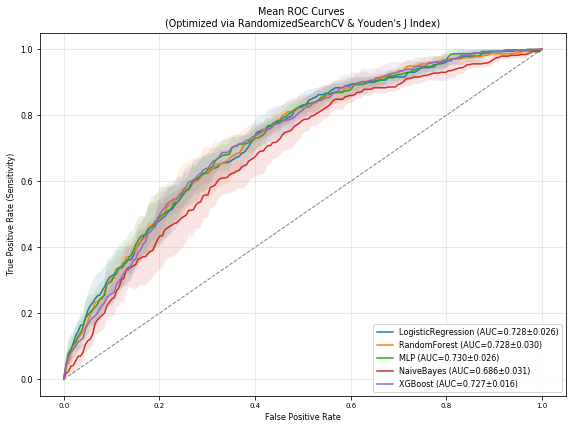

[IterativeImputer] Completing matrix with shape (1652, 16)
[IterativeImputer] Ending imputation round 1/10, elapsed time 0.31
[IterativeImputer] Ending imputation round 2/10, elapsed time 0.68
[IterativeImputer] Ending imputation round 3/10, elapsed time 1.07
[IterativeImputer] Ending imputation round 4/10, elapsed time 1.37
[IterativeImputer] Ending imputation round 5/10, elapsed time 1.66
[IterativeImputer] Ending imputation round 6/10, elapsed time 2.05
[IterativeImputer] Ending imputation round 7/10, elapsed time 2.36
[IterativeImputer] Ending imputation round 8/10, elapsed time 2.66
[IterativeImputer] Ending imputation round 9/10, elapsed time 3.01
[IterativeImputer] Ending imputation round 10/10, elapsed time 3.33
[IterativeImputer] Completing matrix with shape (709, 16)
[IterativeImputer] Ending imputation round 1/10, elapsed time 0.12
[IterativeImputer] Ending imputation round 2/10, elapsed time 0.17
[IterativeImputer] Ending imputation round 3/10, elapsed time 0.27
[IterativeI

,Variable,Coefficient
0,alt_1,0.186083
1,ast_1,-0.063139
2,tg_1,0.268013
3,hdl_1,0.061432
4,ldl_1,0.002642
5,sex,0.110225
6,age_m,-0.186484
7,m_hbsab_1,-0.108844
8,m_smoke_1,-0.034412
9,m_metsatp3_1,0.114824


In [29]:
# ==============================================================================
# PHASE 4: RANDOMIZED SEARCH CV, OPTIMIZATION & COMPARATIVE EVALUATION
# Addressing Reviewer Comments #4 (Model Identity), #5 (PPV/NPV), and #8 (Hyperparameters)
# ==============================================================================
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=UserWarning)

from sklearn.base import clone
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (confusion_matrix, recall_score, accuracy_score, 
                             precision_score, f1_score, average_precision_score, roc_curve)
import matplotlib.pyplot as plt
from tqdm import tqdm

try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except ImportError:
    HAS_XGB = False
    print("XGBoost is not installed. Skipping XGBoost model.")

# Base Settings
N_SPLITS = 5
THRESHOLDS = np.linspace(0.05, 0.95, 91)
OPTIMIZE_METRIC = "youden"

def specificity_score(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return tn / (tn + fp) if (tn + fp) else 0.0

def get_models_and_grids(random_state=RANDOM_STATE):
    scaler = StandardScaler()
    models = {
        "LogisticRegression": Pipeline([("imputer", clone(imputer_base)), ("scaler", scaler), ("clf", LogisticRegression(max_iter=1000, penalty='none', random_state=random_state))]),
        "RandomForest": Pipeline([("imputer", clone(imputer_base)), ("clf", RandomForestClassifier(n_jobs=-1, random_state=random_state))]),
        "MLP": Pipeline([("imputer", clone(imputer_base)), ("scaler", scaler), ("clf", MLPClassifier(max_iter=500, early_stopping=True, random_state=random_state))]),
        "NaiveBayes": Pipeline([("imputer", clone(imputer_base)), ("scaler", scaler), ("clf", GaussianNB())]),
    }
    if HAS_XGB:
        models["XGBoost"] = Pipeline([("imputer", clone(imputer_base)), ("clf", XGBClassifier(random_state=random_state, n_jobs=-1, eval_metric="logloss"))])

    param_grids = {
        "LogisticRegression": {"clf__C": [0.01, 0.1, 1.0, 10.0], "clf__penalty": ["l2", "none"]},
        "RandomForest": {"clf__n_estimators": [200, 300, 400], "clf__max_depth": [None, 5, 10, 15], "clf__min_samples_split": [2, 5, 10]},
        "MLP": {"clf__hidden_layer_sizes": [(32,), (64, 32), (128, 64)], "clf__alpha": [1e-4, 1e-3, 1e-2], "clf__learning_rate_init": [0.001, 0.005, 0.01]},
        "NaiveBayes": {"clf__var_smoothing": [1e-9, 1e-8, 1e-7, 1e-6]},
        "XGBoost": {"clf__learning_rate": [0.01, 0.05, 0.1, 0.2], "clf__max_depth": [3, 4, 5, 6], "clf__n_estimators": [100, 300, 500], "clf__subsample": [0.8, 0.9, 1.0], "clf__colsample_bytree": [0.8, 0.9, 1.0]}
    }
    return models, param_grids

base_models, param_grids = get_models_and_grids(RANDOM_STATE)
tuned_models = {}

print("--- Phase 1: RandomizedSearchCV Hyperparameter Tuning (Reviewer Comment 8) ---")
for name, model in base_models.items():
    if name not in param_grids:
        tuned_models[name] = model
        continue
    print(f"Tuning {name}...")
    search = RandomizedSearchCV(estimator=model, param_distributions=param_grids[name], n_iter=15, scoring='roc_auc', cv=3, random_state=RANDOM_STATE, n_jobs=-1, verbose=0)
    search.fit(X_train, y_train)
    print(f"  -> Best CV AUC: {search.best_score_:.3f}")
    print(f"  -> Selected Hyperparameters: {search.best_params_}") # Printing exactly what Reviewer asked
    tuned_models[name] = search.best_estimator_

# CV and Threshold Evaluation
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
cv_results, test_results, roc_curves_cv = {}, {}, {}

print("\n--- Phase 2: Threshold Optimization & Final Evaluation ---")
with tqdm(total=len(tuned_models)*N_SPLITS, desc="Threshold Optimization CV", leave=True) as pbar:
    for name, model in tuned_models.items():
        mean_fpr = np.linspace(0, 1, 200)
        tprs, aucs_roc = [], []
        metrics_per_thr = {thr: {"accuracy": [], "precision": [], "recall": [], "specificity": [], "f1": [], "youden": []} for thr in THRESHOLDS}

        for tr_idx, val_idx in skf.split(X_train, y_train):
            X_tr, X_val = X_train.iloc[tr_idx], X_train.iloc[val_idx]
            y_tr, y_val = y_train.iloc[tr_idx], y_train.iloc[val_idx]

            m = clone(model)
            m.fit(X_tr, y_tr)

            if hasattr(m, "predict_proba"):
                val_score = m.predict_proba(X_val)[:, 1]
            else:
                val_score = m.decision_function(X_val)
                s_min, s_max = np.min(val_score), np.max(val_score)
                if s_max > s_min: val_score = (val_score - s_min) / (s_max - s_min)

            for thr in THRESHOLDS:
                val_pred = (val_score >= thr).astype(int)
                sens = recall_score(y_val, val_pred)
                spec = specificity_score(y_val, val_pred)
                metrics_per_thr[thr]["accuracy"].append(accuracy_score(y_val, val_pred))
                metrics_per_thr[thr]["precision"].append(precision_score(y_val, val_pred, zero_division=0))
                metrics_per_thr[thr]["recall"].append(sens)
                metrics_per_thr[thr]["specificity"].append(spec)
                metrics_per_thr[thr]["f1"].append(f1_score(y_val, val_pred))
                metrics_per_thr[thr]["youden"].append(sens + spec - 1.0)

            aucs_roc.append(roc_auc_score(y_val, val_score))
            fpr, tpr, _ = roc_curve(y_val, val_score)
            tprs.append(np.interp(mean_fpr, fpr, tpr))
            tprs[-1][0] = 0.0
            pbar.update(1)

        best_thr, best_val = None, -np.inf
        for thr in THRESHOLDS:
            metric_mean = np.mean(metrics_per_thr[thr][OPTIMIZE_METRIC])
            if metric_mean > best_val:
                best_val, best_thr = metric_mean, thr

        mean_tpr = np.mean(tprs, axis=0)
        mean_tpr[-1] = 1.0
        
        cv_results[name] = {
            "best_threshold": best_thr,
            "accuracy": (float(np.mean(metrics_per_thr[best_thr]["accuracy"])), float(np.std(metrics_per_thr[best_thr]["accuracy"]))),
            "recall_sens": (float(np.mean(metrics_per_thr[best_thr]["recall"])), float(np.std(metrics_per_thr[best_thr]["recall"]))),
            "specificity": (float(np.mean(metrics_per_thr[best_thr]["specificity"])), float(np.std(metrics_per_thr[best_thr]["specificity"]))),
            "f1": (float(np.mean(metrics_per_thr[best_thr]["f1"])), float(np.std(metrics_per_thr[best_thr]["f1"]))),
            "youden": (float(np.mean(metrics_per_thr[best_thr]["youden"])), float(np.std(metrics_per_thr[best_thr]["youden"]))),
            "roc_auc": (float(np.mean(aucs_roc)), float(np.std(aucs_roc))),
        }

        roc_curves_cv[name] = {"mean_fpr": mean_fpr, "mean_tpr": mean_tpr, "std_tpr": np.std(tprs, axis=0), "mean_auc": np.mean(aucs_roc), "std_auc": np.std(aucs_roc)}

        final_m = clone(model)
        final_m.fit(X_train, y_train)

        if hasattr(final_m, "predict_proba"):
            test_score = final_m.predict_proba(X_test)[:, 1]
        else:
            test_score = final_m.decision_function(X_test)
            s_min, s_max = np.min(test_score), np.max(test_score)
            if s_max > s_min: test_score = (test_score - s_min) / (s_max - s_min)

        test_pred = (test_score >= best_thr).astype(int)
        sens_test = recall_score(y_test, test_pred)
        spec_test = specificity_score(y_test, test_pred)
        
        # Calculate PPV & NPV (Reviewer Comment 5 Requirement)
        tn, fp, fn, tp = confusion_matrix(y_test, test_pred).ravel()
        ppv_test = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        npv_test = tn / (tn + fn) if (tn + fn) > 0 else 0.0

        test_results[name] = {
            "best_threshold": best_thr, "accuracy": accuracy_score(y_test, test_pred),
            "sensitivity": sens_test, "specificity": spec_test, 
            "PPV": ppv_test, "NPV": npv_test, 
            "f1": f1_score(y_test, test_pred),
            "youden": sens_test + spec_test - 1.0, "roc_auc": roc_auc_score(y_test, test_score),
        }

# Print Tables
def fmt(mstd): return f"{mstd[0]:.3f} ± {mstd[1]:.3f}"

cv_rows = []
for name, res in cv_results.items():
    cv_rows.append({"Model": name, "BestThresh": f"{res['best_threshold']:.2f}", "CV Accuracy": fmt(res["accuracy"]), "CV Sensitivity": fmt(res["recall_sens"]), "CV Specificity": fmt(res["specificity"]), "CV Youden J": fmt(res["youden"]), "CV ROC AUC": fmt(res["roc_auc"])})
cv_df = pd.DataFrame(cv_rows).set_index("Model").sort_values("CV ROC AUC", ascending=False)
print("\n--- 1. INTERNAL CROSS-VALIDATION RESULTS (Train Partition Only) ---")
display(cv_df)

test_rows = []
for name, res in test_results.items():
    test_rows.append({"Model": name, "AppliedThresh": f"{res['best_threshold']:.2f}", "Test Accuracy": f"{res['accuracy']:.3f}", "Test Sensitivity": f"{res['sensitivity']:.3f}", "Test Specificity": f"{res['specificity']:.3f}", "Test PPV": f"{res['PPV']:.3f}", "Test NPV": f"{res['NPV']:.3f}", "Test Youden J": f"{res['youden']:.3f}", "Test ROC AUC": f"{res['roc_auc']:.3f}"})
test_df = pd.DataFrame(test_rows).set_index("Model").sort_values("Test ROC AUC", ascending=False)
print("\n--- 2. LOCKED TEST SET VALIDATION RESULTS (Point Estimates) ---")
display(test_df)

# Plot Mean ROC Curves
plt.figure(figsize=(8,6))
for name, rb in roc_curves_cv.items():
    fpr, tpr, std_tpr = rb["mean_fpr"], rb["mean_tpr"], rb["std_tpr"]
    auc, std_auc = rb["mean_auc"], rb["std_auc"]
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f}±{std_auc:.3f})")
    plt.fill_between(fpr, np.maximum(tpr - std_tpr, 0), np.minimum(tpr + std_tpr, 1), alpha=0.12)

plt.plot([0,1], [0,1], '--', color="grey", lw=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Sensitivity)")
plt.title("Mean ROC Curves \n(Optimized via RandomizedSearchCV & Youden's J Index)")
plt.legend(loc="lower right")
plt.grid(alpha=0.35)
plt.tight_layout()
plt.savefig("mean_ROC_curve_tuned_unbalanced.jpg", dpi=400, format="jpg", bbox_inches="tight")
plt.show()

# Export Main LR parameters & Extract Model Identity (Reviewer Comment 4)
main_model = tuned_models["LogisticRegression"]
main_model.fit(X_train, y_train)
y_prob_main = main_model.predict_proba(X_test)[:, 1]
best_thr = cv_results["LogisticRegression"]["best_threshold"]

print("\n--- 3. LOGISTIC REGRESSION FINAL MODEL IDENTITY (Reviewer Requirement) ---")
lr_clf = main_model.named_steps["clf"]
print(f"Selected Penalty: {lr_clf.penalty}")
print(f"Selected C: {lr_clf.C}")
print(f"Intercept: {lr_clf.intercept_[0]}")
coef_df = pd.DataFrame({'Variable': X_train.columns, 'Coefficient': lr_clf.coef_[0]})
display(coef_df)

In [30]:
# ==============================================================================
# PHASE 5: BOOTSTRAPPED CIs & UNCERTAINTY ESTIMATION FOR ALL MODELS
# Addressing Reviewer Comment #5 (Calibration CIs, Metric CIs, and ML vs LR)
# ==============================================================================
import warnings
warnings.filterwarnings('ignore', category=UserWarning)

from sklearn.utils import resample
import pandas as pd
import numpy as np
from tqdm import tqdm
from sklearn.metrics import confusion_matrix, roc_auc_score, accuracy_score
from sklearn.linear_model import LogisticRegression
from IPython.display import display

print("\n--- PHASE 5: BOOTSTRAPPING FOR 95% CIs & CALIBRATION METRICS ---")

# 1. Generate Test Set Probabilities for ALL Tuned Models
test_probs_all = {}
for name, model in tuned_models.items():
    if hasattr(model, "predict_proba"):
        test_probs_all[name] = model.predict_proba(X_test)[:, 1]
    else:
        scores = model.decision_function(X_test)
        s_min, s_max = np.min(scores), np.max(scores)
        test_probs_all[name] = (scores - s_min) / (s_max - s_min) if s_max > s_min else scores

# 2. Metric Calculation Function for Main Model (LR)
def get_main_metrics(y_t, y_p, thr):
    pred = (y_p >= thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_t, pred).ravel()
    
    # Calculate Calibration Intercept and Slope (Logit equation)
    epsilon = 1e-15
    y_p_clipped = np.clip(y_p, epsilon, 1 - epsilon)
    logit_p = np.log(y_p_clipped / (1 - y_p_clipped)).reshape(-1, 1)
    
    calib_model = LogisticRegression(penalty='none', solver='lbfgs')
    calib_model.fit(logit_p, y_t)
    
    return {
        'Sensitivity': tp / (tp + fn) if (tp + fn) > 0 else 0,
        'Specificity': tn / (tn + fp) if (tn + fp) > 0 else 0,
        'PPV': tp / (tp + fp) if (tp + fp) > 0 else 0,
        'NPV': tn / (tn + fn) if (tn + fn) > 0 else 0,
        'Accuracy': (tp + tn) / (tp + tn + fp + fn) if (tp + tn + fp + fn) > 0 else 0,
        'Calib_Intercept': calib_model.intercept_[0],
        'Calib_Slope': calib_model.coef_[0][0]
    }

# 3. Bootstrapping Setup
np.random.seed(RANDOM_STATE)
boot_main_metrics = {'Sensitivity': [], 'Specificity': [], 'PPV': [], 'NPV': [], 'Accuracy': [], 'Calib_Intercept': [], 'Calib_Slope': []}
boot_all_aucs = {name: [] for name in tuned_models.keys()}

y_test_arr = y_test.values

# 4. Perform Bootstrapping (m=1000)
for i in tqdm(range(1000), desc="Bootstrapping Metrics & AUCs"):
    indices = resample(np.arange(len(y_test_arr)), replace=True)
    y_true_b = y_test_arr[indices]
    
    # Skip if bootstrap sample contains only one class
    if len(np.unique(y_true_b)) < 2: 
        continue
        
    # Main Model Metrics (LR)
    m = get_main_metrics(y_true_b, test_probs_all["LogisticRegression"][indices], best_thr)
    for k in boot_main_metrics: 
        boot_main_metrics[k].append(m[k])
        
    # AUC for all models to prove ML vs LR comparability
    for name in tuned_models.keys():
        boot_all_aucs[name].append(roc_auc_score(y_true_b, test_probs_all[name][indices]))

# 5. Compile and Print Results for Main Model (LR)
print(f"\n--- MAIN MODEL (LR) METRICS WITH 95% CIs (Threshold = {best_thr:.2f}) ---")
main_results = []
for metric in boot_main_metrics:
    mean_val = np.mean(boot_main_metrics[metric])
    ci_lower = np.percentile(boot_main_metrics[metric], 2.5)
    ci_upper = np.percentile(boot_main_metrics[metric], 97.5)
    
    ideal_str = ""
    if metric == 'Calib_Intercept': ideal_str = " (Ideal = 0.0)"
    if metric == 'Calib_Slope': ideal_str = " (Ideal = 1.0)"
    
    main_results.append({
        "Metric": metric,
        "Point Estimate": f"{mean_val:.3f}{ideal_str}",
        "95% CI": f"[{ci_lower:.3f} - {ci_upper:.3f}]"
    })
display(pd.DataFrame(main_results).set_index("Metric"))

# 6. Compile and Print AUC Comparisons Across Models
print("\n--- TEST-SET AUC COMPARISON ACROSS ALL MODELS (With 95% CIs) ---")
print("* Overlapping CIs indicate no statistically significant difference between ML and LR.")
auc_results = []
for name in tuned_models.keys():
    mean_auc = np.mean(boot_all_aucs[name])
    ci_l = np.percentile(boot_all_aucs[name], 2.5)
    ci_u = np.percentile(boot_all_aucs[name], 97.5)
    auc_results.append({
        "Model": name,
        "AUC (Test Set)": f"{mean_auc:.3f}",
        "95% CI": f"[{ci_l:.3f} - {ci_u:.3f}]"
    })
display(pd.DataFrame(auc_results).set_index("Model").sort_values("AUC (Test Set)", ascending=False))


--- PHASE 5: BOOTSTRAPPING FOR 95% CIs & CALIBRATION METRICS ---
[IterativeImputer] Completing matrix with shape (709, 16)
[IterativeImputer] Ending imputation round 1/10, elapsed time 0.09
[IterativeImputer] Ending imputation round 2/10, elapsed time 0.21
[IterativeImputer] Ending imputation round 3/10, elapsed time 0.29
[IterativeImputer] Ending imputation round 4/10, elapsed time 0.36
[IterativeImputer] Ending imputation round 5/10, elapsed time 0.41
[IterativeImputer] Ending imputation round 6/10, elapsed time 0.45
[IterativeImputer] Ending imputation round 7/10, elapsed time 0.49
[IterativeImputer] Ending imputation round 8/10, elapsed time 0.52
[IterativeImputer] Ending imputation round 9/10, elapsed time 0.56
[IterativeImputer] Ending imputation round 10/10, elapsed time 0.61
[IterativeImputer] Completing matrix with shape (709, 16)
[IterativeImputer] Ending imputation round 1/10, elapsed time 0.11
[IterativeImputer] Ending imputation round 2/10, elapsed time 0.15
[IterativeImp

Bootstrapping Metrics & AUCs: 100%|██████████| 1000/1000 [00:19<00:00, 52.33it/s]


--- MAIN MODEL (LR) METRICS WITH 95% CIs (Threshold = 0.20) ---


,Point Estimate,95% CI
Metric,,
Sensitivity,0.787,[0.726 - 0.844]
Specificity,0.561,[0.518 - 0.603]
PPV,0.385,[0.338 - 0.432]
NPV,0.883,[0.846 - 0.916]
Accuracy,0.620,[0.584 - 0.654]
Calib_Intercept,0.012 (Ideal = 0.0),[-0.293 - 0.286]
Calib_Slope,0.990 (Ideal = 1.0),[0.774 - 1.216]



--- TEST-SET AUC COMPARISON ACROSS ALL MODELS (With 95% CIs) ---
* Overlapping CIs indicate no statistically significant difference between ML and LR.


,AUC (Test Set),95% CI
Model,,
LogisticRegression,0.724,[0.682 - 0.765]
RandomForest,0.716,[0.675 - 0.757]
XGBoost,0.713,[0.672 - 0.753]
MLP,0.711,[0.669 - 0.756]
NaiveBayes,0.687,[0.645 - 0.729]


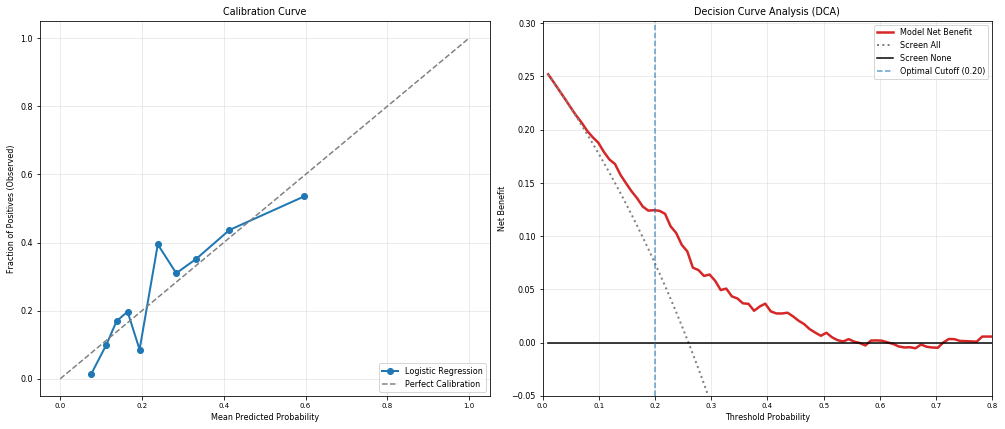

Selected C value: 0.1


In [34]:
# ==============================================================================
# PHASE 6: CALIBRATION CURVE & DECISION CURVE ANALYSIS (DCA) PLOTTING
# ==============================================================================
import numpy as np
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve  # <--- این خط مشکل را حل می‌کند

def calculate_net_benefit(y_true, y_prob, pt_arr):
    net_benefit = []
    N = len(y_true)
    for pt in pt_arr:
        if pt == 1.0:
            net_benefit.append(0)
            continue
        preds = (y_prob >= pt).astype(int)
        tp_count = np.sum((preds == 1) & (y_true == 1))
        fp_count = np.sum((preds == 1) & (y_true == 0))
        nb = (tp_count / N) - (fp_count / N) * (pt / (1 - pt))
        net_benefit.append(nb)
    return np.array(net_benefit)

pt_arr = np.linspace(0.01, 0.99, 100)
nb_model = calculate_net_benefit(y_test.values, y_prob_main, pt_arr)
overall_prevalence = np.mean(y_test.values)
nb_all = overall_prevalence - (1 - overall_prevalence) * (pt_arr / (1 - pt_arr))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 1. Calibration Curve
prob_true, prob_pred = calibration_curve(y_test, y_prob_main, n_bins=10, strategy='quantile')
axes[0].plot(prob_pred, prob_true, marker='o', linewidth=2, color='tab:blue', label='Logistic Regression')
axes[0].plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfect Calibration')
axes[0].set_xlabel("Mean Predicted Probability")
axes[0].set_ylabel("Fraction of Positives (Observed)")
axes[0].set_title("Calibration Curve")
axes[0].legend(loc="lower right")
axes[0].grid(alpha=0.3)

# 2. Decision Curve Analysis (DCA)
axes[1].plot(pt_arr, nb_model, color='tab:red', linewidth=2.5, label='Model Net Benefit')
axes[1].plot(pt_arr, nb_all, color='gray', linestyle=':', linewidth=2, label='Screen All')
axes[1].plot(pt_arr, np.zeros_like(pt_arr), color='black', linewidth=1.5, label='Screen None')
axes[1].axvline(x=best_thr, color='tab:blue', linestyle='--', alpha=0.7, label=f'Optimal Cutoff ({best_thr:.2f})')
axes[1].set_ylim([-0.05, max(np.max(nb_model), np.max(nb_all)) + 0.05])
axes[1].set_xlim([0.0, 0.8]) 
axes[1].set_xlabel("Threshold Probability")
axes[1].set_ylabel("Net Benefit")
axes[1].set_title("Decision Curve Analysis (DCA)")
axes[1].legend(loc="upper right")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("Calibration_DCA.jpg", dpi=400, bbox_inches="tight")
plt.show()
print(f"Selected C value: {tuned_models['LogisticRegression'].named_steps['clf'].C}")

   SENSITIVITY ANALYSIS: EVALUATING FUNCTIONAL FORM OF AGE
Mean Age for Centering: 42.5 years



Imputing & Fitting: 100%|██████████| 10/10 [00:28<00:00,  2.84s/it]


--- MODEL A: Age as Categorical Strata (Reference: <40 years) ---


,Pooled OR,Lower 95% CI,Upper 95% CI,p-value
age_40_49,1.1274,0.8209,1.5484,0.4589
age_50_59,0.8732,0.6045,1.2612,0.4697
age_ge_60,0.4686,0.3069,0.7153,0.0004



--- MODEL B: Mean-Centered Continuous Age (Age + Age^2) ---


,Pooled OR,Lower 95% CI,Upper 95% CI,p-value
age_centered,0.9936,0.9832,1.0042,0.2357
age_squared,0.9021,0.8488,0.9587,0.0009



Generating Non-linear Age Effect Plot...


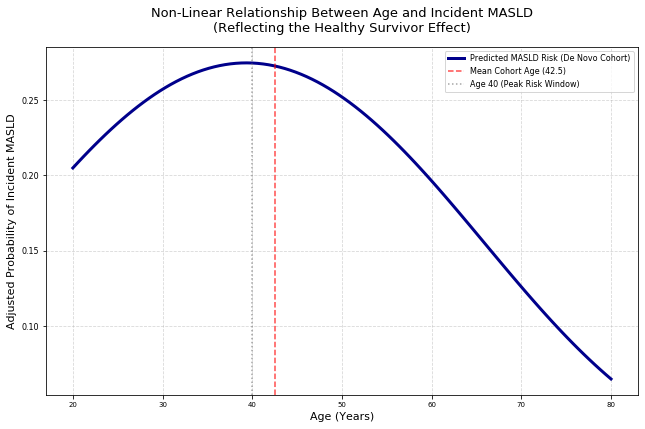

Plot saved successfully as 'Supplementary_Figure_Age_NonLinear.jpg'


In [50]:
# ==============================================================================
# PHASE 9: SENSITIVITY ANALYSIS FOR AGE & VISUALIZATION (Comment 7)
# Corrected for Rebuttal Strata (<40, 40-49, 50-59, >=60) & Convergence
# ==============================================================================
import pandas as pd
import numpy as np
import statsmodels.api as sm
from scipy.stats import norm
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
import matplotlib.pyplot as plt
from tqdm import tqdm
from IPython.display import display
import warnings

warnings.filterwarnings('ignore')

print("="*85)
print("   SENSITIVITY ANALYSIS: EVALUATING FUNCTIONAL FORM OF AGE")
print("="*85)

clinical_increments = {
    'BMI (kg/m^2)': 5.0, 'alt_1': 10.0, 'ast_1': 10.0,
    'tg_1': 10.0, 'hdl_1': 10.0, 'ldl_1': 10.0, 'sbp_mean': 10.0, 'dbp_mean': 10.0
}
binary_cols = ['sex', 'm_hbsab_1', 'm_smoke_1', 'm_metsatp3_1', 'm_lipm_1', 'm_htnm_1', 'm_t2dm_1']

m_imputations = 10
coefs_cat, vars_cat = [], []
coefs_nonlin, vars_nonlin = [], []

mean_age = X_train['age_m'].mean()
print(f"Mean Age for Centering: {mean_age:.1f} years\n")

for i in tqdm(range(m_imputations), desc="Imputing & Fitting"):
    imp = IterativeImputer(max_iter=10, sample_posterior=True, random_state=42 + i, initial_strategy='mean')
    X_imp_m = pd.DataFrame(imp.fit_transform(X_train), columns=X_train.columns)
    
    for col in binary_cols:
        X_imp_m[col] = np.where(X_imp_m[col] > 0.5, 1.0, 0.0)
        
    X_clin = X_imp_m.copy()
    
    # Model A: Age Strata (Ref: <40 years) based on Rebuttal Strategy
    X_clin['age_40_49'] = np.where((X_clin['age_m'] >= 40) & (X_clin['age_m'] <= 49), 1.0, 0.0)
    X_clin['age_50_59'] = np.where((X_clin['age_m'] >= 50) & (X_clin['age_m'] <= 59), 1.0, 0.0)
    X_clin['age_ge_60'] = np.where((X_clin['age_m'] >= 60), 1.0, 0.0)
    
    # Model B: Mean-Centered Non-linear Age
    X_clin['age_centered'] = X_clin['age_m'] - mean_age
    X_clin['age_squared'] = ((X_clin['age_centered']) ** 2) / 100.0 
    
    for col, inc in clinical_increments.items():
        if col in X_clin.columns: 
            X_clin[col] = X_clin[col] / inc
            
    y_sm = y_train.values.astype(float)
    
    cols_cat = [c for c in X_clin.columns if c not in ['age_m', 'age_centered', 'age_squared']]
    X_mat_cat = sm.add_constant(X_clin[cols_cat].astype(float))
    
    cols_nonlin = [c for c in X_clin.columns if c not in ['age_m', 'age_40_49', 'age_50_59', 'age_ge_60']]
    X_mat_nonlin = sm.add_constant(X_clin[cols_nonlin].astype(float))
    
    try:
        mod_cat = sm.Logit(y_sm, X_mat_cat).fit(disp=0, method='newton', maxiter=500)
        coefs_cat.append(mod_cat.params)
        vars_cat.append(mod_cat.bse ** 2)
        
        mod_nonlin = sm.Logit(y_sm, X_mat_nonlin).fit(disp=0, method='newton', maxiter=500)
        coefs_nonlin.append(mod_nonlin.params)
        vars_nonlin.append(mod_nonlin.bse ** 2)
    except Exception as e:
        continue

def apply_rubins_rules(coefs, variances):
    Q_bar = pd.DataFrame(coefs).mean(axis=0)
    U_bar = pd.DataFrame(variances).mean(axis=0)
    B = pd.DataFrame(coefs).var(axis=0, ddof=1)
    T = U_bar + (1 + 1/m_imputations) * B
    SE_pooled = np.sqrt(T)
    
    df = pd.DataFrame({
        "Pooled OR": np.exp(Q_bar),
        "Lower 95% CI": np.exp(Q_bar - 1.96 * SE_pooled),
        "Upper 95% CI": np.exp(Q_bar + 1.96 * SE_pooled),
        "p-value": 2 * (1 - norm.cdf(np.abs(Q_bar / SE_pooled)))
    }).drop(index="const", errors="ignore").round(4)
    return df

print("\n--- MODEL A: Age as Categorical Strata (Reference: <40 years) ---")
if coefs_cat:
    df_cat_res = apply_rubins_rules(coefs_cat, vars_cat)
    display(df_cat_res.loc[['age_40_49', 'age_50_59', 'age_ge_60']])

print("\n--- MODEL B: Mean-Centered Continuous Age (Age + Age^2) ---")
if coefs_nonlin:
    df_nonlin_res = apply_rubins_rules(coefs_nonlin, vars_nonlin)
    display(df_nonlin_res.loc[['age_centered', 'age_squared']])


# ==============================================================================
# VISUALIZATION
# ==============================================================================
if coefs_nonlin:
    print("\nGenerating Non-linear Age Effect Plot...")

    age_range = np.linspace(20, 80, 100)
    age_centered_range = age_range - mean_age
    age_squared_range = (age_centered_range ** 2) / 100.0

    X_pred = pd.DataFrame(index=range(100), columns=X_mat_nonlin.columns)
    for col in X_mat_nonlin.columns:
        X_pred[col] = X_mat_nonlin[col].median()

    X_pred['age_centered'] = age_centered_range
    X_pred['age_squared'] = age_squared_range
    X_pred['const'] = 1.0

    pred_probs = mod_nonlin.predict(X_pred)

    plt.figure(figsize=(9, 6))
    plt.plot(age_range, pred_probs, color='darkblue', linewidth=3, label='Predicted MASLD Risk (De Novo Cohort)')

    plt.axvline(x=mean_age, color='red', linestyle='--', alpha=0.7, label=f'Mean Cohort Age ({mean_age:.1f})')
    plt.axvline(x=40, color='gray', linestyle=':', alpha=0.7, label='Age 40 (Peak Risk Window)')

    plt.title('Non-Linear Relationship Between Age and Incident MASLD\n(Reflecting the Healthy Survivor Effect)', fontsize=13, pad=15)
    plt.xlabel('Age (Years)', fontsize=11)
    plt.ylabel('Adjusted Probability of Incident MASLD', fontsize=11)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend(loc='upper right')
    plt.tight_layout()

    plt.savefig('Supplementary_Figure_Age_NonLinear.jpg', dpi=400, bbox_inches="tight")
    plt.show()
    print("Plot saved successfully as 'Supplementary_Figure_Age_NonLinear.jpg'")

In [36]:
# ==============================================================================
# PHASE 7: INFERENTIAL ASSOCIATION MODEL ON FULL COHORT (TABLE 2)
# Addressing Reviewer Comments #1 (Rubin's Rules) and #4 (Association vs Prediction)
# ==============================================================================
import statsmodels.api as sm
from scipy.stats import norm
import pandas as pd
import numpy as np
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from tqdm import tqdm
from IPython.display import display
from sklearn.metrics import confusion_matrix

print("="*85)
print("   CLINICAL INCREMENT ODDS RATIOS (POOLED ACROSS m=10 IMPUTATIONS) - Table 2")
print("="*85)

clinical_increments = {
    'age_m': 5.0, 'BMI (kg/m^2)': 5.0, 'alt_1': 10.0, 'ast_1': 10.0,
    'tg_1': 10.0, 'hdl_1': 10.0, 'ldl_1': 10.0, 'sbp_mean': 10.0, 'dbp_mean': 10.0
}
binary_cols = ['sex', 'm_hbsab_1', 'm_smoke_1', 'm_metsatp3_1', 'm_lipm_1', 'm_htnm_1', 'm_t2dm_1']
m_imputations = 10

multi_coefs, multi_vars = [], []
crude_coefs = {col: [] for col in X.columns}
crude_vars = {col: [] for col in X.columns}

# Imputation on the FULL dataset (X) strictly for Inferential Table 2
for i in tqdm(range(m_imputations), desc="Imputing & Fitting Models on Full Cohort"):
    imp = IterativeImputer(max_iter=10, sample_posterior=True, random_state=RANDOM_STATE + i, initial_strategy='mean')
    X_imp_m = pd.DataFrame(imp.fit_transform(X), columns=X.columns)
    
    for col in binary_cols:
        X_imp_m[col] = np.where(X_imp_m[col] > 0.5, 1.0, 0.0)
    
    X_clin = X_imp_m.copy()
    for col, inc in clinical_increments.items():
        if col in X_clin.columns: 
            X_clin[col] = X_clin[col] / inc
            
    X_mat = sm.add_constant(X_clin.apply(pd.to_numeric).astype(float))
    y_sm = y.values.astype(float)
    
    # 1. Fit Multivariable Model (FIXED: method='newton', maxiter=500)
    try:
        model_sm = sm.Logit(y_sm, X_mat).fit(disp=0, method='newton', maxiter=500)
        multi_coefs.append(model_sm.params)
        multi_vars.append(model_sm.bse ** 2)
    except:
        pass
        
    # 2. Fit Crude (Univariable) Models (FIXED: method='newton')
    for col in X_clin.columns:
        X_univ = sm.add_constant(X_clin[[col]].apply(pd.to_numeric).astype(float))
        try:
            crude_model = sm.Logit(y_sm, X_univ).fit(disp=0, method='newton', maxiter=500)
            crude_coefs[col].append(crude_model.params[col])
            crude_vars[col].append(crude_model.bse[col] ** 2)
        except:
            pass

# Apply Rubin's Rules
def apply_rubin(coef_list, var_list):
    Q_bar = np.mean(coef_list, axis=0)
    U_bar = np.mean(var_list, axis=0)
    B = np.var(coef_list, axis=0, ddof=1)
    T = U_bar + (1 + 1/m_imputations) * B
    SE = np.sqrt(T)
    
    OR = np.exp(Q_bar)
    CI_L = np.exp(Q_bar - 1.96 * SE)
    CI_U = np.exp(Q_bar + 1.96 * SE)
    pval = 2 * (1 - norm.cdf(np.abs(Q_bar / SE)))
    return OR, CI_L, CI_U, pval

# Pool Multivariable Results
multi_Q_bar = pd.DataFrame(multi_coefs).mean(axis=0) 
multi_U_bar = pd.DataFrame(multi_vars).mean(axis=0)  
multi_B = pd.DataFrame(multi_coefs).var(axis=0, ddof=1) 
multi_T = multi_U_bar + (1 + 1/m_imputations) * multi_B 
multi_SE_pooled = np.sqrt(multi_T)

multi_df = pd.DataFrame({
    "Pooled Multi OR": np.exp(multi_Q_bar),
    "Multi Lower 95% CI": np.exp(multi_Q_bar - 1.96 * multi_SE_pooled),
    "Multi Upper 95% CI": np.exp(multi_Q_bar + 1.96 * multi_SE_pooled),
    "Multi p-value": 2 * (1 - norm.cdf(np.abs(multi_Q_bar / multi_SE_pooled)))
}).drop(index="const", errors="ignore")

# Pool Crude Results
crude_results_list = []
for col in X.columns:
    if len(crude_coefs[col]) > 0:
        c_or, c_cil, c_ciu, c_pval = apply_rubin(crude_coefs[col], crude_vars[col])
        crude_results_list.append({
            "Feature": col,
            "Pooled Crude OR": c_or,
            "Crude Lower 95% CI": c_cil,
            "Crude Upper 95% CI": c_ciu,
            "Crude p-value": c_pval
        })
crude_df = pd.DataFrame(crude_results_list).set_index("Feature")

# Combine and Display Final Table 2
final_coef_table = crude_df.join(multi_df).round(3)
display(final_coef_table)


# ==============================================================================
# PHASE 8: CLINICAL UTILITY METRICS ACROSS THRESHOLDS (SUPP TABLE 4)
# Addressing Reviewer Comments #5 and #9
# ==============================================================================
print("\n" + "="*85)
print("   CLINICAL UTILITY METRICS ACROSS PLAUSIBLE RISK THRESHOLDS (Test Set) - Supp Table 4")
print("="*85)

eval_thresholds = [0.10, 0.15, 0.20, 0.25, 0.26, 0.30, 0.40, 0.50]
utility_rows = []

# Evaluated strictly on the Hold-out Test Set (y_test, y_prob_main from Phase 4)
for thr in eval_thresholds:
    preds = (y_prob_main >= thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, preds).ravel()
    
    sens = tp / (tp + fn) if (tp + fn) > 0 else 0
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0
    ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
    npv = tn / (tn + fn) if (tn + fn) > 0 else 0
    
    utility_rows.append({
        "Threshold": f"> {thr*100:.0f}% Risk", 
        "Sensitivity (%)": sens * 100,
        "Specificity (%)": spec * 100, 
        "PPV (%)": ppv * 100, 
        "NPV (%)": npv * 100,
        "False Positives": fp, 
        "False Negatives": fn
    })

df_utility = pd.DataFrame(utility_rows).set_index("Threshold").round(1)
display(df_utility)

   CLINICAL INCREMENT ODDS RATIOS (POOLED ACROSS m=10 IMPUTATIONS) - Table 2


Imputing & Fitting Models on Full Cohort: 100%|██████████| 10/10 [00:51<00:00,  5.11s/it]


,Pooled Crude OR,Crude Lower 95% CI,Crude Upper 95% CI,Crude p-value,Pooled Multi OR,Multi Lower 95% CI,Multi Upper 95% CI,Multi p-value
Feature,,,,,,,,
alt_1,1.213,1.133,1.300,0.000,1.187,1.074,1.311,0.001
ast_1,1.059,0.955,1.175,0.278,0.876,0.738,1.040,0.130
tg_1,1.054,1.041,1.066,0.000,1.027,1.013,1.042,0.000
hdl_1,0.873,0.819,0.930,0.000,0.991,0.927,1.059,0.785
ldl_1,1.050,1.023,1.079,0.000,1.010,0.980,1.041,0.506
sex,0.829,0.688,0.997,0.047,1.396,1.084,1.796,0.010
age_m,1.007,0.977,1.038,0.637,0.934,0.897,0.973,0.001
m_hbsab_1,0.761,0.618,0.937,0.010,0.740,0.589,0.929,0.009
m_smoke_1,0.813,0.627,1.054,0.118,0.855,0.625,1.169,0.327



   CLINICAL UTILITY METRICS ACROSS PLAUSIBLE RISK THRESHOLDS (Test Set) - Supp Table 4


,Sensitivity (%),Specificity (%),PPV (%),NPV (%),False Positives,False Negatives
Threshold,,,,,,
> 10% Risk,99.5,13.9,28.8,98.6,452,1
> 15% Risk,89.1,37.1,33.2,90.7,330,20
> 20% Risk,78.8,56.4,38.8,88.4,229,39
> 25% Risk,67.9,65.7,41.0,85.4,180,59
> 26% Risk,63.0,67.8,40.7,84.0,169,68
> 30% Risk,53.8,76.6,44.6,82.5,123,85
> 40% Risk,32.1,89.7,52.2,79.0,54,125
> 50% Risk,16.8,94.9,53.4,76.5,27,153


In [37]:
# ==============================================================================
# PHASE 10: EXTRACTING FINAL HYPERPARAMETERS & EXPORTING SUPP TABLE 5
# Addressing Reviewer Comments #4 (Equation Identity) and #8 (Hyperparameters)
# ==============================================================================
import pandas as pd
import numpy as np
from IPython.display import display

print("="*85)
print("   A. FINAL HYPERPARAMETERS FOR ALL MODELS (Reviewer Comment 8)")
print("="*85)

# 1. Print hyperparameters for all tuned models to fully satisfy Comment 8
for name, model in tuned_models.items():
    print(f"\nModel: {name}")
    if name == "LogisticRegression":
        clf = model.named_steps["clf"]
        print(f" - C (Regularization) : {clf.C}")
        print(f" - Penalty            : {clf.penalty}")
        print(f" - Max Iterations     : {clf.max_iter}")
    elif hasattr(model, 'named_steps') and hasattr(model.named_steps['clf'], 'get_params'):
        # For tree-based and MLP models, extract the exact parameters we tuned
        params = model.named_steps['clf'].get_params()
        tuned_keys = param_grids.get(name, {}).keys()
        for k in tuned_keys:
            clean_k = k.replace("clf__", "")
            print(f" - {clean_k:18s} : {params.get(clean_k)}")
    else:
        print(" - Default or non-tuned parameters used.")

print("\n" + "="*85)
print("   B. GENERATING SUPPLEMENTARY TABLE 5 (Exact Predictive Equation)")
print("="*85)

# 2. Recalculate unscaled coefficients from the main predictive model
scaler = main_model.named_steps['scaler']
clf = main_model.named_steps['clf']

coef_scaled = clf.coef_[0]
intercept_scaled = clf.intercept_[0]
means = scaler.mean_
scales = scaler.scale_

# Mathematical unscaling to map coefficients back to raw clinical units
coef_raw = coef_scaled / scales
intercept_raw = intercept_scaled - np.sum((coef_scaled * means) / scales)

# 3. Dictionary mapping exact feature names (ATTENTION: Must match Table 1 exactly)
desc_dict = {
    'alt_1': ('ALT', 'Continuous (U/L)'),
    'ast_1': ('AST', 'Continuous (U/L)'),
    'tg_1': ('Triglycerides', 'Continuous (mg/dL)'),
    'hdl_1': ('HDL Cholesterol', 'Continuous (mg/dL)'),
    'ldl_1': ('LDL Cholesterol', 'Continuous (mg/dL)'),
    'sex': ('Sex', '1 = Male, 0 = Female'),
    'age_m': ('Age', 'Continuous (years)'),
    'm_hbsab_1': ('HBsAb Status', '1 = Positive, 0 = Negative'),
    'm_smoke_1': ('Current Smoker', '1 = Yes, 0 = No'),
    'm_metsatp3_1': ('Metabolic Syndrome (ATP III)', '1 = Yes, 0 = No'),
    'm_lipm_1': ('Lipid-lowering Medication Use', '1 = Yes, 0 = No'),
    # FIXED: Aligned strictly with Table 1 to avoid Reviewer Comment 4 rejection
    'm_htnm_1': ('Hypertension', '1 = Yes (clinical diagnosis or use of antihypertensive medication), 0 = No'),
    'm_t2dm_1': ('Type 2 Diabetes', '1 = Yes (clinical diagnosis or use of anti-diabetic medication), 0 = No'),
    'sbp_mean': ('Systolic Blood Pressure', 'Continuous (mmHg)'),
    'dbp_mean': ('Diastolic Blood Pressure', 'Continuous (mmHg)'),
    'BMI (kg/m^2)': ('Body Mass Index', 'Continuous (kg/m²)')
}

# 4. Build the table rows
rows = []

# Add Intercept as the first row
rows.append({
    "Variable Name in Equation": "Intercept (β0)",
    "Clinical Predictor": "Base Intercept",
    "Coding Instructions / Units": "-",
    "Coefficient (β)": round(intercept_raw, 4)
})

# Add all features
# Note: Using X_train.columns to ensure exact alignment with the training data
for feature_name, coef in zip(X_train.columns, coef_raw):
    predictor, coding = desc_dict.get(feature_name, (feature_name, "-"))
    rows.append({
        "Variable Name in Equation": feature_name,
        "Clinical Predictor": predictor,
        "Coding Instructions / Units": coding,
        "Coefficient (β)": round(coef, 4)
    })

# 5. Create DataFrame and Display
df_supp5 = pd.DataFrame(rows)

print(f"Model Specifications: L2-penalized Logistic Regression (optimized C = {clf.C}).")
print("Note for Reviewer: Coefficients are unscaled mathematically to allow for direct risk calculation using raw clinical values.\n")
display(df_supp5)

# df_supp5.to_excel("Supplementary_Table_5_Final_Equation.xlsx", index=False)

   A. FINAL HYPERPARAMETERS FOR ALL MODELS (Reviewer Comment 8)

Model: LogisticRegression
 - C (Regularization) : 0.1
 - Penalty            : l2
 - Max Iterations     : 1000

Model: RandomForest
 - n_estimators       : 400
 - max_depth          : 5
 - min_samples_split  : 10

Model: MLP
 - hidden_layer_sizes : (128, 64)
 - alpha              : 0.0001
 - learning_rate_init : 0.01

Model: NaiveBayes
 - var_smoothing      : 1e-09

Model: XGBoost
 - learning_rate      : 0.01
 - max_depth          : 6
 - n_estimators       : 300
 - subsample          : 0.8
 - colsample_bytree   : 0.8

   B. GENERATING SUPPLEMENTARY TABLE 5 (Exact Predictive Equation)
Model Specifications: L2-penalized Logistic Regression (optimized C = 0.1).
Note for Reviewer: Coefficients are unscaled mathematically to allow for direct risk calculation using raw clinical values.



,Variable Name in Equation,Clinical Predictor,Coding Instructions / Units,Coefficient (β)
0,Intercept (β0),Base Intercept,-,-6.1686
1,alt_1,ALT,Continuous (U/L),0.0143
2,ast_1,AST,Continuous (U/L),-0.0072
3,tg_1,Triglycerides,Continuous (mg/dL),0.0034
4,hdl_1,HDL Cholesterol,Continuous (mg/dL),0.0044
5,ldl_1,LDL Cholesterol,Continuous (mg/dL),0.0001
6,sex,Sex,"1 = Male, 0 = Female",0.2232
7,age_m,Age,Continuous (years),-0.0121
8,m_hbsab_1,HBsAb Status,"1 = Positive, 0 = Negative",-0.2341
9,m_smoke_1,Current Smoker,"1 = Yes, 0 = No",-0.0925


--- Generating SHAP values on strictly Imputed Dataset ---
[IterativeImputer] Completing matrix with shape (2361, 16)
[IterativeImputer] Ending imputation round 1/10, elapsed time 0.16
[IterativeImputer] Ending imputation round 2/10, elapsed time 0.34
[IterativeImputer] Ending imputation round 3/10, elapsed time 0.53
[IterativeImputer] Ending imputation round 4/10, elapsed time 0.68
[IterativeImputer] Ending imputation round 5/10, elapsed time 0.85
[IterativeImputer] Ending imputation round 6/10, elapsed time 1.04
[IterativeImputer] Ending imputation round 7/10, elapsed time 1.19
[IterativeImputer] Ending imputation round 8/10, elapsed time 1.34
[IterativeImputer] Ending imputation round 9/10, elapsed time 1.45
[IterativeImputer] Ending imputation round 10/10, elapsed time 1.57


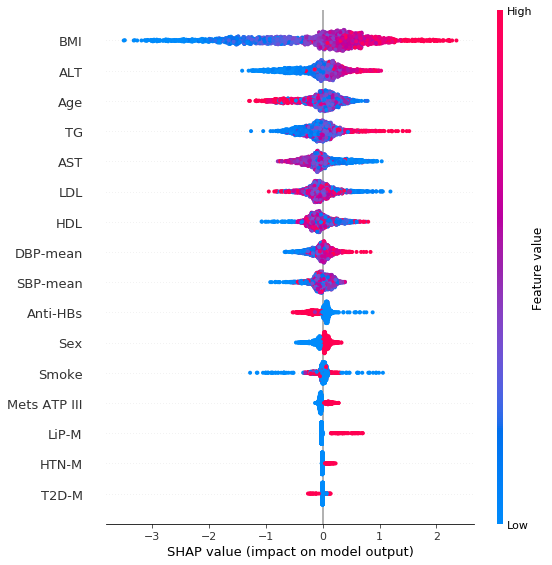

In [38]:
# ==============================================================================
# اضافه کردن کتابخانه‌های مورد نیاز
# ==============================================================================
import shap
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# ==============================================================================
# PHASE 8: XGBoost SHAP SUMMARY PLOT (CORRECTED FOR DATA LEAKAGE)
# ==============================================================================
print("--- Generating SHAP values on strictly Imputed Dataset ---")

# Transform the entire X using the imputer fitted ONLY on X_train to prevent data leakage
X_shap_imp = pd.DataFrame(imputer_base.transform(X), columns=X.columns, index=X.index)

# Fit XGBoost on the properly imputed dataset (Natural Prevalence)
xgb_shap = XGBClassifier(
    n_estimators=600, learning_rate=0.05, max_depth=4, subsample=0.9,
    colsample_bytree=0.9, reg_lambda=3.0, random_state=RANDOM_STATE,
    n_jobs=-1, eval_metric="logloss"
)
xgb_shap.fit(X_shap_imp, y)

# Sample rows for SHAP speed
MAX_ROWS = 2000
if len(X_shap_imp) > MAX_ROWS:
    rng = np.random.default_rng(RANDOM_STATE)
    samp_idx = rng.choice(X_shap_imp.index, size=MAX_ROWS, replace=False)
    X_for_shap = X_shap_imp.loc[samp_idx]
else:
    X_for_shap = X_shap_imp.copy()

# Rename for display
name_map = {
    "BMI (kg/m^2)": "BMI", "m_sld_1": "Baseline SLD", "alt_1": "ALT",
    "age_m": "Age", "ast_1": "AST", "tg_1": "TG", "sex": "Sex",
    "m_hbsab_1": "Anti-HBs", "dbp_mean": "DBP-mean", "m_fbs_1": "FBS",
    "m_smoke_1": "Smoke", "m_lipm_1": "LiP-M", "hdl_1": "HDL",
    "m_htnm_1": "HTN-M", "sbp_mean": "SBP-mean", "m_t2dm_1": "T2D-M",
    "ldl_1": "LDL", "m_metsatp3_1": "Mets ATP III"
}
X_disp = X_for_shap.rename(columns=name_map)

# SHAP Explainer
explainer = shap.TreeExplainer(xgb_shap)

MM_TO_IN = 1 / 25.4
plt.figure(figsize=(107 * MM_TO_IN, 80 * MM_TO_IN))
plt.rcParams.update({"font.size": 8, "axes.labelsize": 8, "xtick.labelsize": 7, "ytick.labelsize": 8})

try:
    explanation = explainer(X_for_shap)
    shap.summary_plot(explanation.values, features=X_disp, feature_names=X_disp.columns, show=False)
except Exception:
    shap_values = explainer.shap_values(X_for_shap)
    shap.summary_plot(shap_values, features=X_disp, feature_names=X_disp.columns, show=False)

plt.tight_layout()
plt.savefig("shap_summary_107mm_300dpi.jpg", dpi=300, bbox_inches="tight")
plt.show()

--- BENCHMARKING: FULL MODEL VS. PARSIMONIOUS VS. HSI ---

[Discrimination - Test Set AUC]
Full Model (16): 0.724 (95% CI: 0.682 to 0.765)
Parsimonious(4): 0.722 (95% CI: 0.680 to 0.761)
HSI Score      : 0.726 (95% CI: 0.684 to 0.768)

[Calibration - Parsimonious Model]
Slope          : 0.964 (95% CI: 0.751 to 1.182)
Intercept      : -0.009 (95% CI: -0.294 to 0.279)

[Calibration - HSI]
Slope          : 1.093 (95% CI: 0.829 to 1.395)
Intercept      : 0.069 (95% CI: -0.246 to 0.409)


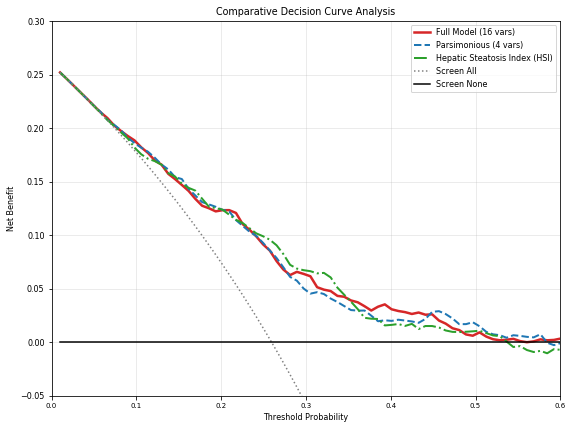

In [53]:
# ==============================================================================
# PHASE 12: BENCHMARKING AGAINST SIMPLER APPROACHES (Reviewer Comment #6)
# (Full Model vs. Parsimonious vs. HSI)
# ==============================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.utils import resample
import warnings
warnings.filterwarnings('ignore')

print("--- BENCHMARKING: FULL MODEL VS. PARSIMONIOUS VS. HSI ---")

# 1. Fit Parsimonious Model (4 Predictors)
simple_vars = ['age_m', 'BMI (kg/m^2)', 'alt_1', 'tg_1']
pars_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(penalty='none', max_iter=1000))
])
pars_pipeline.fit(X_train_imp[simple_vars], y_train)
y_prob_pars = pars_pipeline.predict_proba(X_test_imp[simple_vars])[:, 1]

# 2. Calculate Hepatic Steatosis Index (HSI)
def calc_hsi(df):
    return 8 * (df['alt_1'] / df['ast_1']) + df['BMI (kg/m^2)'] + \
           np.where(df['sex'] == 0, 2, 0) + np.where(df['m_t2dm_1'] == 1, 2, 0)

hsi_train = calc_hsi(X_train_imp).values.reshape(-1, 1)
hsi_test = calc_hsi(X_test_imp).values.reshape(-1, 1)

hsi_lr = LogisticRegression(penalty='none')
hsi_lr.fit(hsi_train, y_train)
y_prob_hsi = hsi_lr.predict_proba(hsi_test)[:, 1]

# 3. Bootstrapping for AUC and Calibration
def get_calib_metrics(y_t, y_p):
    eps = 1e-15
    y_p_clip = np.clip(y_p, eps, 1 - eps)
    logit_p = np.log(y_p_clip / (1 - y_p_clip)).reshape(-1, 1)
    calib = LogisticRegression(penalty='none', solver='lbfgs').fit(logit_p, y_t)
    return calib.coef_[0][0], calib.intercept_[0]

boot_metrics = {
    'Full_AUC': [], 'Pars_AUC': [], 'HSI_AUC': [],
    'Pars_Slope': [], 'Pars_Int': [], 'HSI_Slope': [], 'HSI_Int': []
}

np.random.seed(42)
for _ in range(1000):
    idx = resample(np.arange(len(y_test)), replace=True)
    y_t_b = y_test.iloc[idx].values
    if len(np.unique(y_t_b)) < 2: continue
    
    boot_metrics['Full_AUC'].append(roc_auc_score(y_t_b, y_prob_main[idx]))
    boot_metrics['Pars_AUC'].append(roc_auc_score(y_t_b, y_prob_pars[idx]))
    boot_metrics['HSI_AUC'].append(roc_auc_score(y_t_b, y_prob_hsi[idx]))
    
    p_slope, p_int = get_calib_metrics(y_t_b, y_prob_pars[idx])
    h_slope, h_int = get_calib_metrics(y_t_b, y_prob_hsi[idx])
    
    boot_metrics['Pars_Slope'].append(p_slope)
    boot_metrics['Pars_Int'].append(p_int)
    boot_metrics['HSI_Slope'].append(h_slope)
    boot_metrics['HSI_Int'].append(h_int)

def print_ci(name, data):
    mean_v = np.mean(data)
    l_ci, u_ci = np.percentile(data, [2.5, 97.5])
    print(f"{name:15s}: {mean_v:.3f} (95% CI: {l_ci:.3f} to {u_ci:.3f})")

print("\n[Discrimination - Test Set AUC]")
print_ci("Full Model (16)", boot_metrics['Full_AUC'])
print_ci("Parsimonious(4)", boot_metrics['Pars_AUC'])
print_ci("HSI Score", boot_metrics['HSI_AUC'])

print("\n[Calibration - Parsimonious Model]")
print_ci("Slope", boot_metrics['Pars_Slope'])
print_ci("Intercept", boot_metrics['Pars_Int'])

print("\n[Calibration - HSI]")
print_ci("Slope", boot_metrics['HSI_Slope'])
print_ci("Intercept", boot_metrics['HSI_Int'])

# 4. Comparative Decision Curve Analysis (DCA)
def calc_net_benefit(y_t, y_p, pt_arr):
    nb = []
    N = len(y_t)
    for pt in pt_arr:
        if pt == 1.0:
            nb.append(0)
            continue
        preds = (y_p >= pt).astype(int)
        tp = np.sum((preds == 1) & (y_t == 1))
        fp = np.sum((preds == 1) & (y_t == 0))
        nb.append((tp / N) - (fp / N) * (pt / (1 - pt)))
    return np.array(nb)

pt_arr = np.linspace(0.01, 0.8, 100)
nb_full = calc_net_benefit(y_test.values, y_prob_main, pt_arr)
nb_pars = calc_net_benefit(y_test.values, y_prob_pars, pt_arr)
nb_hsi = calc_net_benefit(y_test.values, y_prob_hsi, pt_arr)

prev = np.mean(y_test.values)
nb_all = prev - (1 - prev) * (pt_arr / (1 - pt_arr))

plt.figure(figsize=(8, 6))
plt.plot(pt_arr, nb_full, color='tab:red', linewidth=2.5, label='Full Model (16 vars)')
plt.plot(pt_arr, nb_pars, color='tab:blue', linestyle='--', linewidth=2, label='Parsimonious (4 vars)')
plt.plot(pt_arr, nb_hsi, color='tab:green', linestyle='-.', linewidth=2, label='Hepatic Steatosis Index (HSI)')
plt.plot(pt_arr, nb_all, color='gray', linestyle=':', linewidth=1.5, label='Screen All')
plt.plot(pt_arr, np.zeros_like(pt_arr), color='black', linewidth=1.5, label='Screen None')

plt.ylim([-0.05, 0.3])
plt.xlim([0.0, 0.6])
plt.xlabel("Threshold Probability")
plt.ylabel("Net Benefit")
plt.title("Comparative Decision Curve Analysis")
plt.legend(loc="upper right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("Comparative_DCA_Benchmark.jpg", dpi=400)
plt.show()